# `PyTorch` without `torchvision`

Educational CNN on a curated flower-photo subset (`data/flower_photos_mini`). Uses `torch` only for the model and training loop — image I/O and resizing via `skimage` / `numpy`.

### (i) Setup and preprocessing

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from skimage.io import imread
from skimage.transform import resize
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn import (
    AdaptiveAvgPool2d,
    BatchNorm2d,
    Conv2d,
    CrossEntropyLoss,
    Dropout,
    Linear,
    MaxPool2d,
    ReLU,
    Sequential,
)
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

DATA_ROOT = Path("data/flower_photos_mini")
TRAIN_DIR = DATA_ROOT / "training_set"
TEST_DIR = DATA_ROOT / "test_set"
IMG_SIZE = 96
SEED = 42
BATCH_SIZE = 32
N_EPOCHS = 50
torch.manual_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = ["tulips", "daisy", "dandelion", "sunflowers", "roses"]
label_map = {name: i for i, name in enumerate(CLASS_NAMES)}
inv_label = {i: name for name, i in label_map.items()}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [2]:
train = pd.read_csv(TRAIN_DIR / "training.csv").rename(columns={"Id": "id"})
train["label"] = train["label"].map(label_map)
print(train["label"].map(inv_label).value_counts().sort_index())
train.head()


label
daisy         150
dandelion     150
roses         150
sunflowers    150
tulips        150
Name: count, dtype: int64


,label,id,image_type
0,1,10172567486_2748826a8b,.jpg
1,1,10172636503_21bededa75_n,.jpg
2,1,1031799732_e7f4008c03,.jpg
3,1,10437770546_8bb6f7bdd3_m,.jpg
4,1,10466290366_cc72e33532,.jpg


#### Preprocessor

In [3]:
def load_image(path: Path) -> np.ndarray:
    """Read an RGB image, resize, and scale to float32 in [0, 1]."""
    img = imread(path)
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    if img.shape[-1] == 4:
        img = img[..., :3]
    img = resize(img, (IMG_SIZE, IMG_SIZE, 3), anti_aliasing=True, preserve_range=True)
    img = img.astype(np.float32)
    # per-image min-max keeps the demo dependency-light (no ImageNet stats)
    lo, hi = float(img.min()), float(img.max())
    img = (img - lo) / (hi - lo + 1e-8)
    return img


def load_split(data_dir: Path, labels_df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    images: list[np.ndarray] = []
    for _, row in tqdm(labels_df.iterrows(), total=len(labels_df), desc=data_dir.name):
        path = data_dir / f"{row['id']}{row['image_type']}"
        images.append(load_image(path))
    x = np.asarray(images, dtype=np.float32)
    y = labels_df["label"].to_numpy(dtype=np.int64)
    return x, y


train_x, train_y = load_split(TRAIN_DIR, train)
train_x.shape, train_y.shape


training_set:   0%|          | 0/750 [00:00<?, ?it/s]

training_set:   2%|▏         | 13/750 [00:00<00:06, 120.31it/s]

training_set:   4%|▍         | 31/750 [00:00<00:04, 149.86it/s]

training_set:   7%|▋         | 51/750 [00:00<00:04, 169.82it/s]

training_set:   9%|▉         | 69/750 [00:00<00:04, 161.25it/s]

...

training_set:  93%|█████████▎| 694/750 [00:03<00:00, 179.45it/s]

training_set:  95%|█████████▌| 713/750 [00:04<00:00, 174.19it/s]

training_set:  98%|█████████▊| 732/750 [00:04<00:00, 177.74it/s]

training_set: 100%|██████████| 750/750 [00:04<00:00, 177.53it/s]

((750, 96, 96, 3), (750,))

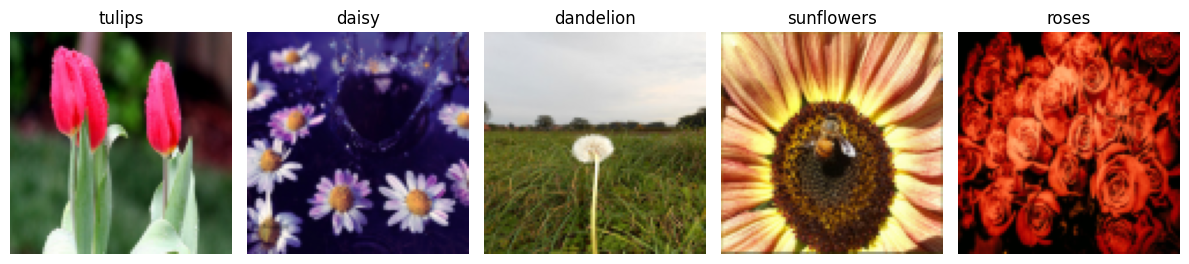

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax, class_id in zip(axes, range(5)):
    idx = int(np.where(train_y == class_id)[0][0])
    ax.imshow(train_x[idx])
    ax.set_title(inv_label[class_id])
    ax.axis("off")
plt.tight_layout()
plt.show()


In [5]:
train_x, val_x, train_y, val_y = train_test_split(
    train_x, train_y, test_size=0.15, random_state=SEED, stratify=train_y
)
train_x.shape, val_x.shape, train_y.shape, val_y.shape


((637, 96, 96, 3), (113, 96, 96, 3), (637,), (113,))

In [6]:
class FlowerTensorDataset(Dataset):
    """NCHW float tensors with optional train-time flips / light noise."""

    def __init__(self, x: np.ndarray, y: np.ndarray, augment: bool = False) -> None:
        self.x = torch.from_numpy(np.transpose(x, (0, 3, 1, 2)))
        self.y = torch.from_numpy(y)
        self.augment = augment

    def __len__(self) -> int:
        return int(self.x.shape[0])

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        img = self.x[idx]
        y = self.y[idx]
        if self.augment:
            if torch.rand(()) < 0.5:
                img = torch.flip(img, dims=(2,))
            if torch.rand(()) < 0.5:
                img = torch.flip(img, dims=(1,))
            # mild brightness jitter
            img = (img * (0.85 + 0.3 * torch.rand(()))).clamp(0.0, 1.0)
        return img, y


train_loader = DataLoader(
    FlowerTensorDataset(train_x, train_y, augment=True),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_loader = DataLoader(
    FlowerTensorDataset(val_x, val_y, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
len(train_loader.dataset), len(val_loader.dataset)


(637, 113)

### (ii) Model and training (`torch` only)

In [7]:
def conv_block(in_ch: int, out_ch: int) -> Sequential:
    return Sequential(
        Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
        BatchNorm2d(out_ch),
        ReLU(inplace=True),
        Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
        BatchNorm2d(out_ch),
        ReLU(inplace=True),
        MaxPool2d(2),
    )


class Net(nn.Module):
    def __init__(self, n_classes: int = 5) -> None:
        super().__init__()
        self.features = Sequential(
            conv_block(3, 32),   # 96 -> 48
            conv_block(32, 64),  # 48 -> 24
            conv_block(64, 128), # 24 -> 12
        )
        self.head = Sequential(
            AdaptiveAvgPool2d(1),
            nn.Flatten(),
            Dropout(0.35),
            Linear(128, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.features(x))


model = Net().to(device)
optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
criterion = CrossEntropyLoss(label_smoothing=0.05)
print(model)
print("params", sum(p.numel() for p in model.parameters() if p.requires_grad))


Net(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=Tr

In [8]:
@torch.no_grad()
def evaluate(loader: DataLoader) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * yb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_n += yb.size(0)
    return total_loss / total_n, total_correct / total_n


def train_one_epoch(loader: DataLoader) -> tuple[float, float]:
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * yb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_n += yb.size(0)
    return total_loss / total_n, total_correct / total_n


train_losses: list[float] = []
val_losses: list[float] = []
val_accs: list[float] = []
best_val_acc = -1.0
best_state = None

for epoch in range(N_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(train_loader)
    va_loss, va_acc = evaluate(val_loader)
    scheduler.step()
    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    val_accs.append(va_acc)
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if epoch % 5 == 0 or epoch == N_EPOCHS - 1:
        print(
            f"epoch={epoch+1:02d}  train_loss={tr_loss:.3f}  val_loss={va_loss:.3f}  "
            f"train_acc={tr_acc:.2f}  val_acc={va_acc:.2f}  lr={scheduler.get_last_lr()[0]:.2e}"
        )

assert best_state is not None
model.load_state_dict(best_state)
print(f"best val accuracy: {best_val_acc:.3f}")


epoch=01  train_loss=1.407  val_loss=1.809  train_acc=0.42  val_acc=0.20  lr=3.00e-04


epoch=06  train_loss=1.049  val_loss=1.066  train_acc=0.62  val_acc=0.65  lr=2.89e-04


epoch=11  train_loss=0.949  val_loss=0.958  train_acc=0.66  val_acc=0.68  lr=2.66e-04


epoch=16  train_loss=0.874  val_loss=1.015  train_acc=0.71  val_acc=0.72  lr=2.30e-04


epoch=21  train_loss=0.799  val_loss=1.077  train_acc=0.76  val_acc=0.63  lr=1.87e-04


...

epoch=31  train_loss=0.698  val_loss=0.965  train_acc=0.82  val_acc=0.72  lr=9.48e-05


epoch=36  train_loss=0.690  val_loss=0.917  train_acc=0.82  val_acc=0.68  lr=5.44e-05


epoch=41  train_loss=0.651  val_loss=0.907  train_acc=0.85  val_acc=0.68  lr=2.34e-05


epoch=46  train_loss=0.649  val_loss=0.914  train_acc=0.84  val_acc=0.70  lr=4.71e-06


epoch=50  train_loss=0.635  val_loss=0.910  train_acc=0.84  val_acc=0.71  lr=0.00e+00
best val accuracy: 0.726


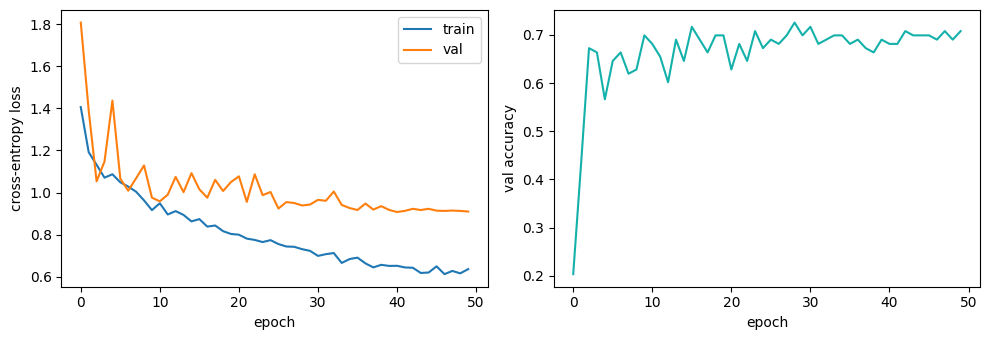

test_set:   0%|          | 0/200 [00:00<?, ?it/s]

test_set:   9%|▉         | 18/200 [00:00<00:01, 177.22it/s]

test_set:  18%|█▊        | 36/200 [00:00<00:01, 148.63it/s]

test_set:  26%|██▌       | 52/200 [00:00<00:01, 147.81it/s]

test_set:  34%|███▎      | 67/200 [00:00<00:01, 132.48it/s]

...

test_set:  82%|████████▏ | 163/200 [00:01<00:00, 151.31it/s]

test_set:  90%|████████▉ | 179/200 [00:01<00:00, 147.09it/s]

test_set:  98%|█████████▊| 196/200 [00:01<00:00, 152.26it/s]

test_set: 100%|██████████| 200/200 [00:01<00:00, 146.30it/s]

holdout accuracy (test_set): 0.695
              precision    recall  f1-score   support

      tulips      0.600     0.675     0.635        40
       daisy      0.739     0.850     0.791        40
   dandelion      0.727     0.800     0.762        40
  sunflowers      0.838     0.775     0.805        40
       roses      0.536     0.375     0.441        40

    accuracy                          0.695       200
   macro avg      0.688     0.695     0.687       200
weighted avg      0.688     0.695     0.687       200



In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses, label="val")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy loss")
axes[0].legend()
axes[1].plot(val_accs, color="#14b1ab")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("val accuracy")
plt.tight_layout()
plt.show()

holdout = pd.read_csv(TEST_DIR / "testing.csv").rename(columns={"Id": "id"})
holdout["label"] = holdout["label"].map(label_map)
holdout_x, holdout_y = load_split(TEST_DIR, holdout)
holdout_loader = DataLoader(
    FlowerTensorDataset(holdout_x, holdout_y, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
holdout_loss, holdout_acc = evaluate(holdout_loader)

model.eval()
preds: list[int] = []
with torch.no_grad():
    for xb, _ in holdout_loader:
        preds.extend(model(xb.to(device)).argmax(dim=1).cpu().tolist())

print(f"holdout accuracy (test_set): {holdout_acc:.3f}")
print(classification_report(holdout_y, preds, target_names=CLASS_NAMES, digits=3))


### Notes

- Class indices are **0–4** (`tulips`, `daisy`, `dandelion`, `sunflowers`, `roses`) for `CrossEntropyLoss`.
- Train-time augmentation is flip / brightness only (implemented in `torch`, not `torchvision`).
